In [3]:
using Revise

using PyPlot
using LinearAlgebra
using Cosmology
using QuadGK
using HCubature
using Trapz
using Dierckx
using CMBLensing
using JLD2

using HaloMF
import MatterPower

# using BenchmarkTools

In [4]:
# Cosmological parameters
# As, ns, kpivot = 2.097e-9, 0.9652, 0.05
# Ωm, ΩΛ, Ωb = 0.315, 0.685, 0.049
# Ωk = 1 - Ωm - ΩΛ
# h₀ = 0.674
As, ns, kpivot = 2.46e-9, 0.96, 0.002
Ωm, ΩΛ, Ωb = 0.23+0.044, 1-(0.23+0.044), 0.044
Ωk = 1 - Ωm - ΩΛ
h₀ = 0.704
ωm, fb = Ωm * h₀^2, Ωb / Ωm

# Other params
Yp = 0.24

# Constants
const σT = 6.6524587321e-29 # [m²] Thomson cross-section
const G  = 6.6743e-11 # [m³⋅kg⁻¹⋅s⁻²] Newton const
const mp = 1.6726219e-27 # [kg] proton mass
const c_kms = 299792.458 # [km/s] speed of light
const km2Mpc = 3.240779289469756e-20
const Mpc2m = 3.0856775814671917e+22

# Critical density today
ρc₀ = 3 * (100h₀*km2Mpc)^2/(8π*G) # kg/m³

# Hubble function
H(z::Real) = 100h₀ * √(Ωm*(1+z)^3+ΩΛ) # km/s/Mpc

# Comoving distance
χ(z::Real) = QuadGK.quadgk(zed->1/H(zed), 0, z, rtol=1e-3)[1] * c_kms # Mpc
χlss = χ(1089);

# Lookup table χ <--> z
χtoz = Spline1D(χ.(vcat(range(0,10,length=100), range(10.1,1100,length=100))), vcat(range(0,10,length=100), range(10.1,1100,length=100)), k=1)

Spline1D(knots=[0.0,421.006 … 14108.1,14110.6] (200 elements), k=1, extrapolation="nearest", residual=0.0)

In [5]:
# Mean ionization fraction
function x̄ₑ(z::Real; zre=7., Δz=1., f=1.)
    y(x::Real) = (1+x)^(1.5)
    yre = y(zre)
    Δy = 1.5 * sqrt(1+zre) * Δz
    f/2 * (1 + tanh((yre-y(z))/Δy))
end

# Homogeneous Optical depth
function τ̄(z::Real; zre=7., Δz=1., f=1., npts=100)
    ρb₀ = ρc₀ * Ωb # kg/m³
    fact = σT * (1-0.75Yp) * ρb₀ / mp # m⁻¹
    zarr = range(0,z,length=npts)
    dτdz = @. x̄ₑ(zarr, zre=zre, Δz=Δz, f=f) * (1+zarr)^2 / H(zarr)
    trapz(zarr,dτdz) * fact * c_kms * Mpc2m 
#     dτdz_func(zed) = x̄ₑ(zed, zre=zre, Δz=Δz, f=f) * (1+zed)^2 / H(zed)
#     QuadGK.quadgk(dτdz_func, 0, z, rtol=1e-3)[1] * fact * c_kms * Mpc2m
end

# Distribution of the bubble sizes
function P(R::Real; R̄=5., σlnR=log(2))
    exp(-((log(R/R̄)^2)/(2σlnR^2)))/sqrt(2π*σlnR^2)/R
end

# Volume
V(R::Real) = 4π * R^3/3
V̄b(R̄=5., σlnR=log(2)) = 4π * R̄^3 * exp(4.5σlnR^2)/3
V̄²b(R̄=5., σlnR=log(2)) = (4π)^2 * R̄^6 * exp(18σlnR^2)/ 9

# Filtering window function (Fourier transform of a top-hat in real space) 
# W(x::Real) = 3x^(-3) * (sin(x)-x*cos(x))
W(k::Real, R::Real) = 3(k*R)^(-3) * (sin(k*R)-(k*R)*cos(k*R))

# Filter functions
function Wᵣ(k::Real; R̄=5., σlnR=log(2), Rmax=50,npts=300)
#     dWᵣdR_func(r) = P(r,R̄=R̄,σlnR=σlnR) * V(r) * W(k,r) 
#     QuadGK.quadgk(dWᵣdR_func, 0, Inf, rtol=1e-3)[1] / V̄b(R̄,σlnR)
    R = range(1e-3,Rmax,length=npts)
    dWᵣdR = @. P(R,R̄=R̄,σlnR=σlnR) * V(R) * W(k,R)
    trapz(R,dWᵣdR) / V̄b(R̄,σlnR)
end

function Wᵣ_new_quad(k::Real; R̄=5., σlnR=log(2), χmax=Inf)
    κ = k*R̄
    dWᵣdχ_func(χ) = χ^2 * exp(-(log(χ)^2)/(2σlnR^2)) * (sin(κ*χ)- κ*χ*cos(κ*χ))/(κ*χ)^3
    QuadGK.quadgk(dWᵣdχ_func, 0, χmax, rtol=1e-2)[1] * (3exp(-9σlnR^2/2)/(√(2π)σlnR))
end

function W²ᵣ(k::Real; R̄=5., σlnR=log(2), Rmax=300,npts=100)
#     dW²ᵣdR_func(r) = P(r,R̄=R̄,σlnR=σlnR) * V(r)^2 * W(k*r)^2 
#     QuadGK.quadgk(dW²ᵣdR_func, 0, Rmax, rtol=1e-3)[1] / V̄b(R̄,σlnR)^2
    R = range(1e-3,Rmax,length=npts)
    dW²ᵣdR = @. P(R,R̄=R̄,σlnR=σlnR) * V(R)^2 * W(k,R)^2
    trapz(R,dW²ᵣdR) / V̄b(R̄,σlnR)^2
end  

function W²ᵣ_quad(k::Real; R̄=5., σlnR=log(2), χmax=Inf)
    κ = k*R̄
    dW²ᵣdχ_func(χ) = χ^5 * exp(-(log(χ)^2)/(2σlnR^2)) * (sin(κ*χ)- κ*χ*cos(κ*χ))^2/(κ*χ)^6
    QuadGK.quadgk(dW²ᵣdχ_func, 0, χmax, rtol=1e-2)[1] * (9exp(-9σlnR^2)/(√(2π)σlnR))
end        

# Mass threshold
Mth(z::Real; ωh²=0.143, Tvir=5e4) = (10/(1+z))^1.5 * (0.15/ωh²)^2 * (Tvir/1e4)^1.5 * (1/1.1)^1.5 * 1e8 #M⊙


Mth (generic function with 1 method)

In [6]:
# Tabulate linear growth factor as a function of scale factor, a
sol = MatterPower.setup_growth(Ωm, ΩΛ)
# a = 1 / (1 + redshift)
# D1 = sol(a)[1]

# Matter power spectrum Pδδ
"""
pk(k,red) = 
   sol(1 / (1 + red))[1,:].^2 *
   As * (k / kpivot)^(ns - 1) *
   (2 * k^2 * 2998^2 / 5 / Ωm)^2 *
   MatterPower.t_nowiggle(k, ωm, fb)^2 *
   2 * π^2 / k^3
"""

function pk(k,red) 
   kovh = k / h₀
   sol(1 / (1 + red))[1,:].^2 *
   As * (k / kpivot)^(ns - 1) *
   (2 * kovh^2 * 2998^2 / 5 / Ωm)^2 *
   MatterPower.t_nowiggle(k, ωm, fb)^2 *
   2 * π^2 / k^3
end

pk (generic function with 1 method)

In [7]:
logks = log(1e-4):0.01:log(100)
ks = exp.(logks)
zs = vcat(range(0,10,length=100), range(10.1,1100,length=100));

pkz = zeros((length(ks),length(zs)))
for i in 1:length(zs)
    pkz[:,i] = vcat(pk.(ks,zs[i])...)
end

# Matter power spectrum spline
pkz_spl = Spline2D(ks,zs,pkz,); 

In [8]:
M2R(M::Real, ρ̄₀::Real) = ∛((3M)/(4π * ρ̄₀))

function sigma2(pk, z::Real, R::Real, Rmax=300,npts=50)
   function dσ2dk(k)
      x = k * R
      W = (3 / x) * (sin(x) / x^2 - cos(x) / x)
      dσ2dk = W^2 * pk(k,z) * k^2 / 2 / π^2
   end
    ks = range(1e-4,20/R,length=npts)
#     println(dσ2dk.(ks))
    integ = @. dσ2dk(ks)
    integ = vcat(integ...)
    trapz(ks,integ)
#    res, err = QuadGK.quadgk(dσ2dk, 0, 20 / R, rtol=1e-2)
#    res[1]
end

function sigma2M(pk, z::Real, M::Real, ρ̄₀::Real)
    R = M2R(M,ρ̄₀)
    res, err = QuadGK.quadgk(k->dσ2dk(k,z)[1], 0, 20 / R, rtol=1e-4)
    σ2 = res
end

function sigma2Rbubble(pk, z::Real; R̄=5., σlnR=log(2), Rmax=300,npts=50)
    R = range(1e-3,Rmax,length=npts)
    dsigma2 = @. P(R,R̄=R̄,σlnR=σlnR) * V(R)^2 * sigma2(pk, z, R)
    trapz(R,dsigma2) / V̄b(R̄,σlnR)^2
#     dsigma2(R) = P(R,R̄=R̄,σlnR=σlnR) * V(R)^2 * sigma2(pk, z, R)
#     QuadGK.quadgk(dsigma2, 0, Inf, rtol=1e-2)[1] / V̄b(R̄,σlnR)^2
end

function sigma2RbubbleMeerburg(pk, z::Real; R̄=5., σlnR=log(2), Rmax=300,npts=50)
   function dσ2dk(k)
      dσ2dk = W²ᵣ_quad(k, R̄=R̄, σlnR=σlnR) * pk(k,z) * k^2 / 2 / π^2
   end
    ks = range(1e-4,20,length=npts)
    integ = @. dσ2dk(ks)
    integ = vcat(integ...)
    trapz(ks,integ)
end


sigma2RbubbleMeerburg (generic function with 1 method)

In [9]:
√(sigma2(pk, 0, 8))

1.0280152249646286

In [10]:
sigma2(pk, 0, 8)

1.0568153027590759

# 3D electron (x density) power spectra

### $P_{\delta x_e\delta x_e}^{2h}= \left[(1-\bar{x}_e)ln(1-\bar{x}_e)b \langle W_R\rangle(k)\right]^2 P_{\delta\delta}(k)$
### $P_{\delta x_e\delta x_e}^{1h}= \bar{x}_e(1-\bar{x}_e)\left[\langle V_b \rangle \langle W^2_R\rangle(k) + \frac{P_{\delta\delta}(k)\langle V_b\rangle\langle \sigma_R^2 \rangle}{\sqrt{P_{\delta\delta}^2(k)+(\langle V_b\rangle\langle \sigma_R^2 \rangle)^2}}\right] $
### $P_{\delta x_e\delta}^{2h}= \left[\bar{x}_e - (1-\bar{x}_e)ln(1-\bar{x}_e)b \langle W_R\rangle(k)\right] P_{\delta\delta}(k)$
### $P_{\delta x_e\delta}^{1h} \simeq 0 $

In [11]:
# α(k; R̄=5., Rmax=200) = QuadGK.quadgk(R->P(R)*(V(R)*W(R*k)),0, Rmax, rtol=1e-4)[1]/Vb(R̄)

function P̃δδ(pk, k::Real, z::Real; R̄=5, σlnR=log(2))
    σ²b = sigma2Rbubble(pk, z, R̄=R̄, σlnR=σlnR)
    pkz_int = pk(k,z)[1]
    vb = V̄b(R̄,σlnR)
    num = pkz_int * σ²b * vb
    den = √(pkz_int^2 + (σ²b*vb)^2)
    num/den
end

function Pee1h(pk, k::Real, z::Real; R̄=5, σlnR=log(2), zre=7., Δz=1.)
    """
    Eq 17 from https://arxiv.org/pdf/astro-ph/0607652.pdf
    """
    xe = x̄ₑ(z, zre=zre, Δz=Δz)
    xe * (1-xe) * ( W²ᵣ_quad(k, R̄=R̄, σlnR=σlnR) * V̄b(R̄,σlnR) + P̃δδ(pk, k, z; R̄=R̄, σlnR=σlnR))
end

function Pee2h(pk, k::Real, z::Real; R̄=5, σlnR=log(2), zre=7., Δz=1., b=6.)
    """
    Eq 31 from https://arxiv.org/pdf/astro-ph/0607652.pdf
    """
    xe = x̄ₑ(z, zre=zre, Δz=Δz)
    xH = 1 - xe
    W  = Wᵣ_new_quad(k, R̄=R̄, σlnR=σlnR)
    # (xH*log(xH)*b*W)^2 * pk(k,z)[1]
    (xH*log(xH)*b*W-xe)^2 * pk(k,z)[1]
end

function Pee(pk, k::Real, z::Real; R̄=5, σlnR=log(2), zre=7., Δz=1., b=6.)
    Pee1h(pk, k, z; R̄=R̄, σlnR=σlnR, zre=zre, Δz=Δz) + Pee2h(pk, k, z; R̄=R̄, σlnR=σlnR, zre=zre, Δz=Δz, b=b)
end


function Pδe(pk, k::Real, z::Real; R̄=5, σlnR=log(2), zre=7., Δz=1., b=6.)
    xe = x̄ₑ(z, zre=zre, Δz=Δz)
    xH = 1 - xe
    W  = Wᵣ_new_quad(k, R̄=R̄, σlnR=σlnR)
    (xe - xH*log(xH)*b*W) * pk(k,z)[1]
end


# function PHI2h(pk, k::Real, z::Real; R̄=5, σlnR=log(2), zre=7., Δz=1., b=6.)
#     xH = 1 - x̄ₑ(z, zre=zre, Δz=Δz)
#     W  = Wᵣ_new_quad(k, R̄=R̄, σlnR=σlnR)
#     beff  = log(xH)*b*W + 1
#     xH^2*beff^2*pk(k,z)
# end

# function PHI1h(pk, k::Real, z::Real; R̄=5, σlnR=log(2), zre=7., Δz=1., b=6.)
#     xe = x̄ₑ(z, zre=zre, Δz=Δz)
#     W² = W²ᵣ_quad(k, R̄=R̄, σlnR=σlnR)
#     vb = V̄b(R̄,σlnR)
#     (xe-xe^2) * (vb*W² + P̃δδ(pk, k, z, R̄=R̄, σlnR=σlnR))
# end

# function Pxψ2h(pk, k::Real, z::Real; R̄=5, σlnR=log(2), zre=7., Δz=1., b=6.)
#     xH = 1 - x̄ₑ(z, zre=zre, Δz=Δz)
#     W  = Wᵣ_new_quad(k, R̄=R̄, σlnR=σlnR)
#     Q  = xH*log(xH)*b*W + xH
#     Q*(1-Q)*pk(k,z)
# end


Pδe (generic function with 1 method)

In [12]:
# CMB lensing converence κ kernel
Wκ(z::Real) = 1.5 * Ωm / c_kms * (100h₀)^2/H(z) * (1+z) * χ(z) * (1 - χ(z)/χlss) # unitless

Wκ (generic function with 1 method)

## Some plots

### Mean ionization fraction history

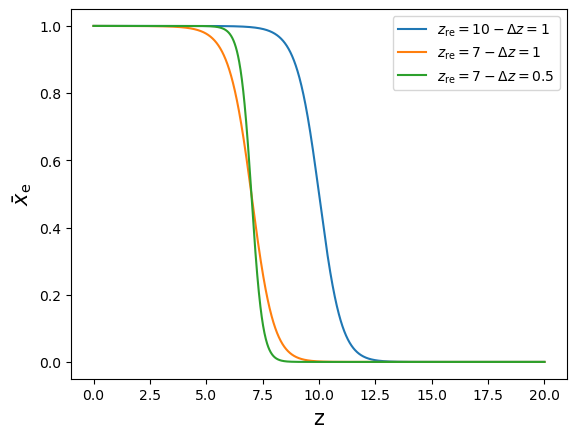

PyObject <matplotlib.legend.Legend object at 0x1554c292e610>

In [13]:
plot(0:0.01:20, x̄ₑ.(0:0.01:20, zre=10, Δz=1), label=L"z_{\rm re}=10 - \Delta z =1")
plot(0:0.01:20, x̄ₑ.(0:0.01:20), label=L"z_{\rm re}=7 - \Delta z =1")
plot(0:0.01:20, x̄ₑ.(0:0.01:20, Δz=0.5), label=L"z_{\rm re}=7 - \Delta z =0.5")
xlabel("z", size=15)
ylabel(L"x̄_{\rm e}", size=15)
legend()

### Mean optical depth $\tau$

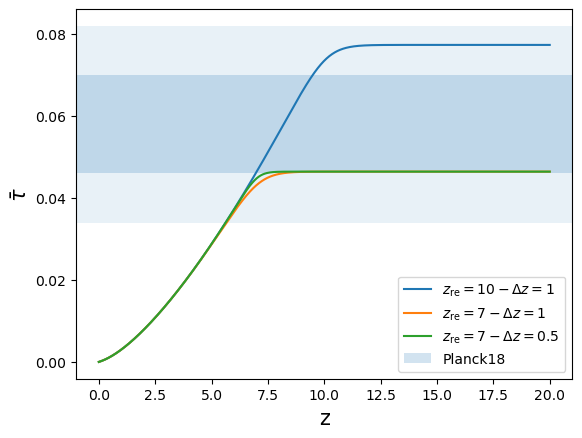

PyObject <matplotlib.legend.Legend object at 0x1554be7c03a0>

In [14]:
plot(0:0.01:20, τ̄.(0:0.01:20, zre=10, Δz=1), label=L"z_{\rm re}=10 - \Delta z =1")
plot(0:0.01:20, τ̄.(0:0.01:20), label=L"z_{\rm re}=7 - \Delta z =1")
plot(0:0.01:20, τ̄.(0:0.01:20, Δz=0.5), label=L"z_{\rm re}=7 - \Delta z =0.5")
axhspan(0.058-0.012, 0.058+0.012, alpha=0.2, label="Planck18")
axhspan(0.058-2*0.012, 0.058+2*0.012, alpha=0.1)
xlabel("z", size=15)
ylabel(L"τ̄", size=15)
legend()


### Bubble size distribution

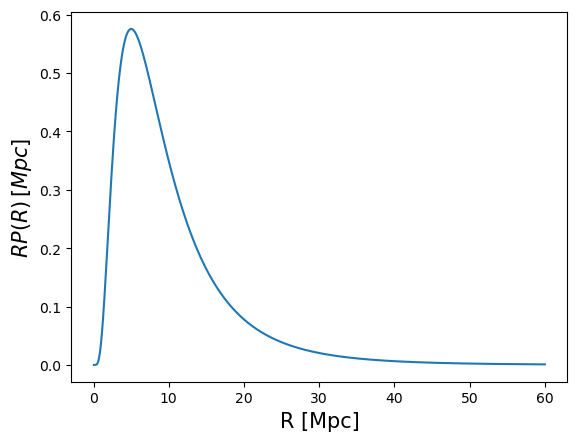

PyObject Text(34.00000000000001, 0.5, '$R P(R)\\, [Mpc]$')

In [15]:
plot(0:0.05:60, collect(0:0.05:60).*P.(0:0.05:60))
xlabel("R [Mpc]", size=15)
ylabel(L"R P(R)\, [Mpc]", size=15)

### Filter functions (see e.g. Fig 2 and 3 from https://arxiv.org/pdf/astro-ph/0607652.pdf)

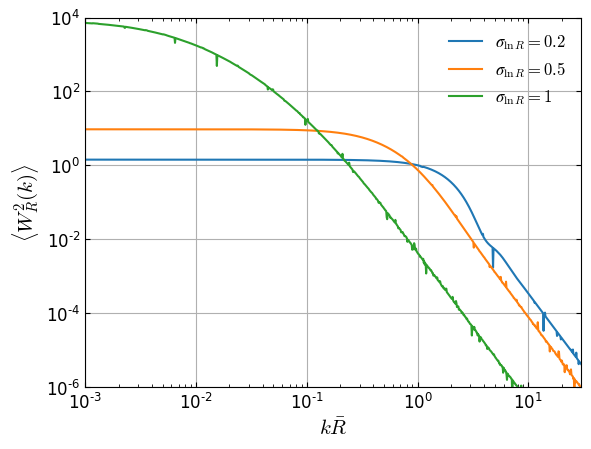

In [14]:
loglog(ks*5,  W²ᵣ_quad.(ks,σlnR=0.2) ,label=L"σ_{\ln R}=0.2")
loglog(ks*5,  W²ᵣ_quad.(ks,σlnR=0.5) ,label=L"σ_{\ln R}=0.5")
loglog(ks*5,  W²ᵣ_quad.(ks,σlnR=1  ),label=L"σ_{\ln R}=1")
# semilogx(1e-3:0.001:10, W²ᵣ.(1e-3:0.001:10),label=L"W^2_R(k)")
xlabel(L"k \bar{R}", size=15)
ylabel(L"\langle W^2_R(k) \rangle", size=15)
legend()
ylim(1e-6,1e4)
xlim(1e-3,30)
grid()


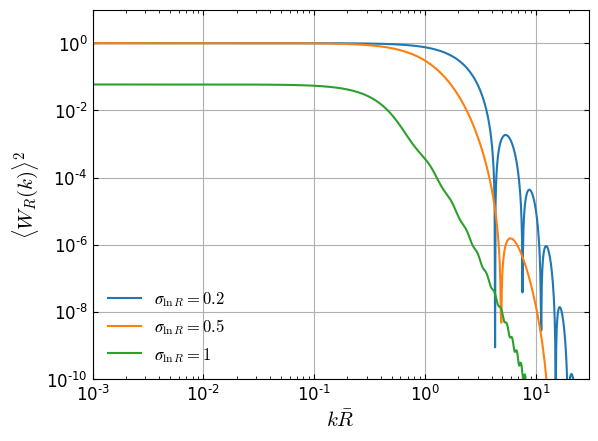

In [15]:
loglog(ks*5,  Wᵣ.(ks,σlnR=0.2,npts=300, Rmax=50).^2 ,label=L"σ_{\ln R}=0.2")
loglog(ks*5,  Wᵣ.(ks,σlnR=0.5,npts=300, Rmax=50).^2 ,label=L"σ_{\ln R}=0.5")
loglog(ks*5,  Wᵣ.(ks,σlnR=1  ,npts=300, Rmax=50).^2,label=L"σ_{\ln R}=1")
# semilogx(1e-3:0.001:10, W²ᵣ.(1e-3:0.001:10),label=L"W^2_R(k)")
xlabel(L"k \bar{R}", size=15)
ylabel(L"\langle W_R(k) \rangle ^2", size=15)
legend()
ylim(1e-10,10)
xlim(1e-3,30)
grid()

### Bubbles shot-noise

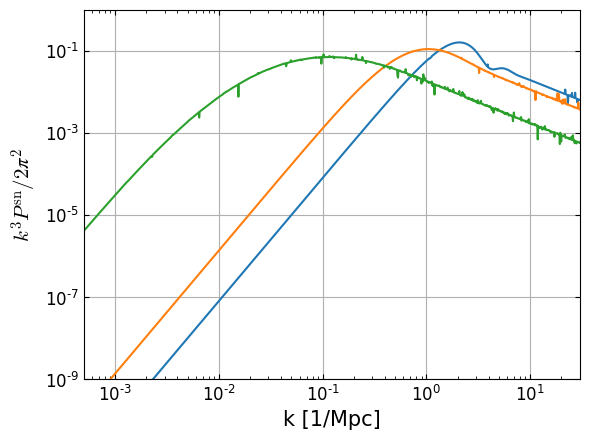

PyObject Text(39.1716796875, 0.5, '$k^3 P^{\\rm sn}/2π^2$')

In [16]:
z=11
zre=10
Δz=3
r̄ = 1
Δxₑ = x̄ₑ(z, zre=zre, Δz=Δz)-x̄ₑ(z, zre=zre, Δz=Δz)^2

for σ in [0.2, 0.5, 1.0]
    loglog(ks, @. Δxₑ*ks^3*W²ᵣ_quad(ks, R̄=r̄, σlnR=σ)*V̄b(r̄,σ)/2π^2)#, label=L"\sigma_{\rm lnR}=%d"%σ)
end
# legend()
xscale("log")
yscale("log")
grid()
xlim(5e-4,30)
ylim(1e-9,1)
xlabel("k [1/Mpc]", size=15)
ylabel(L"k^3 P^{\rm sn}/2π^2", size=15)

In [17]:
# z=11.
# zre=10.
# Δz=3.
# r̄=1.
# Δxₑ = x̄ₑ(z, zre=zre, Δz=Δz)-x̄ₑ(z, zre=zre, Δz=Δz)^2

# for σ in [0.2]#, 0.5, 1.0]
#     loglog(ks_, @. Δxₑ*ks_^3*P̃δδ(pk, ks_, z, R̄=r̄, σlnR=σ)/2π^2)
#     loglog(ks, @. Δxₑ*ks^3*W²ᵣ_quad(ks, R̄=r̄, σlnR=σ)*V̄b(r̄,σ)/2π^2)
# end
# # legend()
# xscale("log")
# yscale("log")
# grid()
# xlim(5e-4,30)
# # ylim(1e-12,2e-3)
# xlabel("k [1/Mpc]", size=15)
# ylabel(L"k^3 P^{1h}_{ee}/2π^2", size=15)

### Minimum mass for collapse

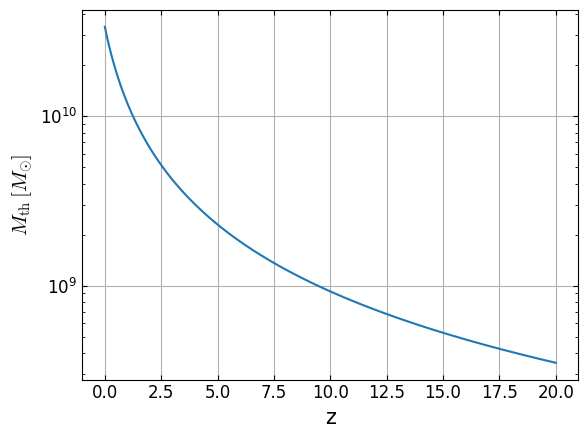

In [18]:
semilogy(0:0.1:20, Mth.(0:0.1:20))
xlabel("z", size=15)
ylabel(L"M_{\rm th} \, [M_{\odot}]", size=15)
# legend()
grid()

### CMB lensing kernel

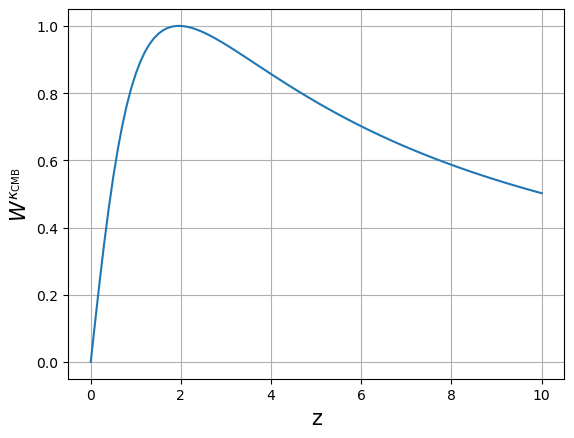

In [16]:
plot(0:0.1:10, Wκ.(0:0.1:10)/maximum(Wκ.(0:0.1:10)))
xlabel("z", size=15)
# xlim(0,4)
ylabel(L"W^{\kappa_{\rm CMB}}" , size=15)
# legend()
grid()

## Let's calculate some angular power spectra

In [17]:
zs = vcat(range(0,10,length=100), range(10.1,1100,length=100));

In [18]:
pkz_spl = Spline2D(ks,zs,pkz,);

### CMB lensing power spectrum (just to check we're doing things the right way)

In [19]:
function GetCℓκκ(W₁, W₂=nothing, ℓmax=2000; zmin=1e-4, zmax=1089, kmin=1e-4, kmax=1e2, npts=100, limb_fact=0.5)
    if (W₂ == nothing); W₂ = W₁; end

    ℓrange = 2:ℓmax
    χmin = χ(zmin)
    χmax = χ(zmax)
    χs = range(χmin,χmax,length=npts)
    zs = χtoz(χs)
    dz = diff(zs)
    insert!(dz,1,0)
        
    fact = @. H(zs) / χs^2 / c_kms
    kern = @. W₁(zs) * W₂(zs)
    K =  transpose(collect((ℓrange .+ limb_fact))' ./ collect(χs)) # array with wavenumber k for (ℓ,z) combo, i.e. K[i,j] = ℓᵢ/χⱼ
#     K =  transpose(collect((ℓrange .+ limb_fact))' ./ collect(χs) /h₀) # array with wavenumber k for (ℓ,z) combo, i.e. K[i,j] = ℓᵢ/χⱼ
    Z = transpose(repeat(zs, 1, length(ℓrange))) 
    
    Mᵢⱼ = zeros((length(ℓrange),length(zs))) # Mij contains Pδδ(ℓᵢ/χⱼ; zⱼ) 
    for i in 1:length(zs)
        Mᵢⱼ[:,i] = pkz_spl(K[:,i],Z[:,i])
    end
    
    Mᵢⱼ[K .< kmin] .= 0
    Mᵢⱼ[K .≥ kmax] .= 0 

    vⱼ = @. kern * fact * dz 
#     vⱼ = @. kern * fact * dz / h₀^3

    Mᵢⱼ * vⱼ 
end

GetCℓκκ (generic function with 3 methods)

In [20]:
ℓrange = 2:2000

2:2000

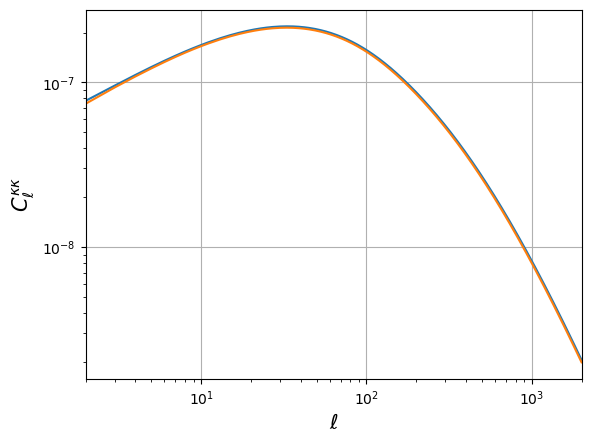

PyObject Text(36.8, 0.5, '$C_ℓ^{κκ}$')

In [21]:
loglog(ℓrange,GetCℓκκ(Wκ))
loglog(ℓrange,GetCℓκκ(Wκ,npts=50))
grid()
xlim(2,2000)
xlabel(L"\ell", size=15)
ylabel(L"C_ℓ^{κκ}", size=15)

In [23]:
logkssm = log(1e-4):0.5:log(10)
kssm = exp.(logkssm);

### Optical depth power spectrum

## $C_L^{\tau\tau} = \int \frac{\sigma_T^2 n_{p0}^2}{a^4\chi^2} P_{\delta x_e\delta x_e}(k=\ell/\chi,\chi)$

In [25]:
# function GetCℓττ(ℓmax=2000; zmin=1e-4, zmax=20, kmin=1e-4, kmax=1e1, npts=25, limb_fact=0.5, R̄=5, σlnR=log(2), zre=10., Δz=2., b=6)
function GetCℓττ(ℓs=nothing; zmin=1e-4, zmax=20, kmin=1e-4, kmax=1e1, npts=25, limb_fact=0.5, R̄=5, σlnR=log(2), zre=10., Δz=2., b=6)
    np₀ = (1-0.75Yp) * ρc₀ * Ωb / mp # m^-³
    
    χmin = χ(zmin)
    χmax = χ(zmax)
    χs = range(χmin,χmax,length=npts)
    zs = χtoz(χs)
    as = @. 1/(1+zs)
    dχ = diff(χs)
    insert!(dχ,1,0)
    
    # ℓmax = ℓmax <= 2000 ? 3000 : ℓmax
    # ℓrange=[10,50,100,300,500,700,1000,1500,2000,ℓmax]
    if ℓs == nothing
        ℓrange=[10,50,100,150,200,250,300,350,400,500,700,1000,1500,2000,2500,3000,3500,4000,4500,5000,6000,7000]
    end


    kern = @. (1+zs)^4 / χs^2 
    K = transpose(collect((ℓrange .+ limb_fact))' ./ collect(χs)) # array with wavenumber k for (ℓ,z) combo, i.e. K[i,j] = ℓᵢ/χⱼ
    Z = transpose(repeat(zs, 1, length(ℓrange))) 

    Mᵢⱼ = zeros((length(ℓrange),length(χs))) # Mij contains Pee(ℓᵢ/χⱼ; χⱼ) 

    
    for i in 1:length(zs)
        Mᵢⱼ[:,i] = Pee.(pk, K[:,i],Z[:,i][1], R̄=R̄, σlnR=σlnR, zre=zre, Δz=Δz, b=b)
    end
    
    Mᵢⱼ[K .< kmin] .= 0
    Mᵢⱼ[K .≥ kmax] .= 0 

    vⱼ = @. kern * dχ 

    cl = Mᵢⱼ * vⱼ * np₀^2 * σT^2 * Mpc2m^2
        
    Spline1D(ℓrange, cl)

end

GetCℓττ (generic function with 2 methods)

In [27]:
clττ = GetCℓττ(Δz=5);

In [28]:
clττ2 = GetCℓττ();

In [29]:
clττ3 = GetCℓττ(R̄=1);

In [26]:
ℓrange = 2:2000

2:2000

## Similar plots can be found in e.g.https://arxiv.org/pdf/1801.02393.pdf (fig 8)

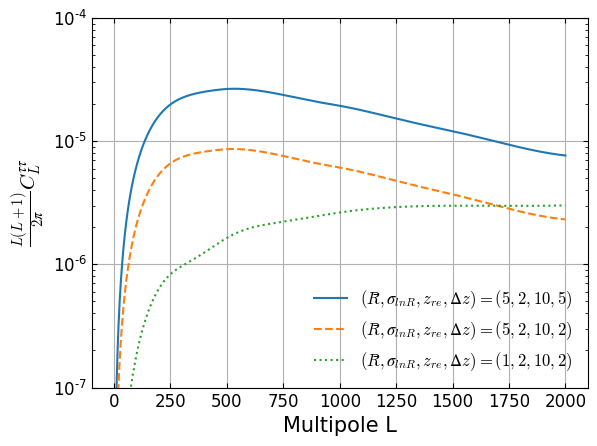

PyObject Text(47.310416666666654, 0.5, '$\\frac{L(L+1)}{2π}C_L^{ττ}$')

In [31]:
semilogy(collect(ℓrange), collect(ℓrange).^2 .* clττ(ℓrange)/2π,           label=L"(R̄,σ_{lnR},z_{re},Δz)=(5,2,10,5)")
semilogy(collect(ℓrange), collect(ℓrange).^2 .* clττ2(ℓrange)/2π, ls="--", label=L"(R̄,σ_{lnR},z_{re},Δz)=(5,2,10,2)")
semilogy(collect(ℓrange), collect(ℓrange).^2 .* clττ3(ℓrange)/2π, ls=":",  label=L"(R̄,σ_{lnR},z_{re},Δz)=(1,2,10,2)")
legend()
ylim(1e-7,1e-4)
# xlim(0,2e3)
grid()
xlabel("Multipole L", size=15)
ylabel(L"\frac{L(L+1)}{2π}C_L^{ττ}", size=15)

### n=20 points of i

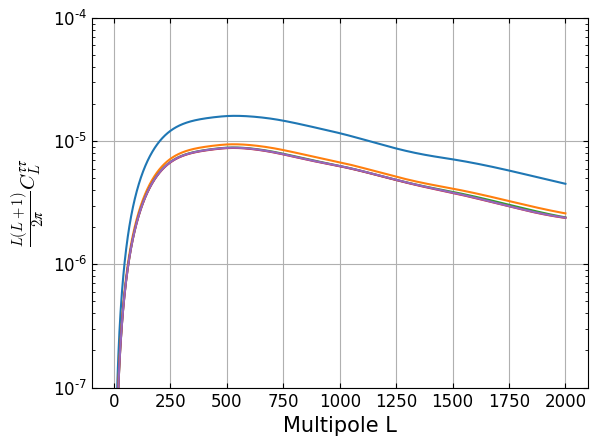

PyObject Text(47.310416666666654, 0.5, '$\\frac{L(L+1)}{2π}C_L^{ττ}$')

In [32]:
for n in [10,20,30,40,100]
    cltmp = GetCℓττ(npts=n,kmax=10)
    semilogy(collect(ℓrange), collect(ℓrange).^2 .* cltmp(ℓrange)/2π)
end
ylim(1e-7,1e-4)
# xlim(0,2e3)
grid()
xlabel("Multipole L", size=15)
ylabel(L"\frac{L(L+1)}{2π}C_L^{ττ}", size=15)

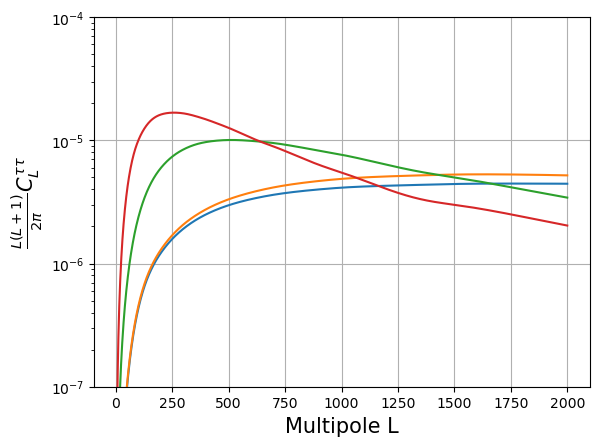

PyObject Text(45.01041666666667, 0.5, '$\\frac{L(L+1)}{2π}C_L^{ττ}$')

In [27]:
for r in [0.1,1,5,10,]
    cltmp = GetCℓττ(R̄=r)
    semilogy(collect(ℓrange), collect(ℓrange).^2 .* cltmp(ℓrange) /2π,)
end
ylim(1e-7,1e-4)
# xlim(0,2e3)
grid()
xlabel("Multipole L", size=15)
ylabel(L"\frac{L(L+1)}{2π}C_L^{ττ}", size=15)

In [34]:
test = GetCℓττ(Δz=5);

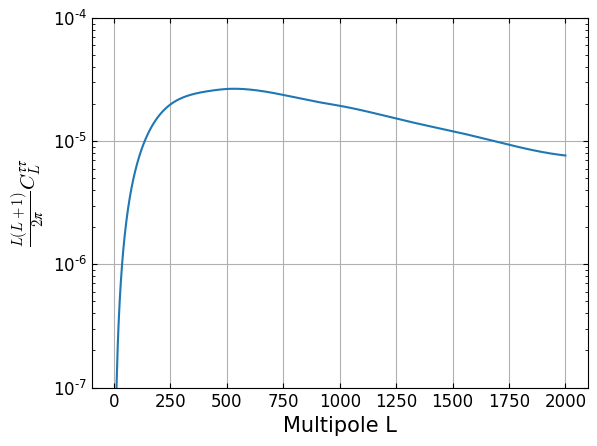

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


PyObject Text(47.310416666666654, 0.5, '$\\frac{L(L+1)}{2π}C_L^{ττ}$')

In [35]:
semilogy(collect(ℓrange), collect(ℓrange).^2 .* test(ℓrange)/2π,)
# semilogy(collect(ℓrange), collect(ℓrange).^2 .* test_new(ℓrange)/2π,)
legend()
ylim(1e-7,1e-4)
# xlim(0,2e3)
grid()
xlabel("Multipole L", size=15)
ylabel(L"\frac{L(L+1)}{2π}C_L^{ττ}", size=15)

# CMB lensing - electron cross-spectrum

## $C_L^{\phi\tau} =  \frac{3H_0^2\Omega_m \sigma_T n_{p0}}{c\ell^2} \int \frac{d\chi}{a^3} \frac{\chi^*-\chi}{\chi*\chi} P_{\delta\delta x_e}(k=\ell/\chi,\chi)$

In [28]:
# function GetCℓτϕ(ℓmax=2000; zmin=1e-4, zmax=20, kmin=1e-4, kmax=1e1, npts=25, limb_fact=0.5, R̄=5, σlnR=log(2), zre=10., Δz=2., b=6)
function GetCℓτϕ(ℓs=nothing; zmin=1e-4, zmax=20, kmin=1e-4, kmax=1e1, npts=25, limb_fact=0.5, R̄=5, σlnR=log(2), zre=10., Δz=2., b=6)
    np₀ = (1-0.75Yp) * ρc₀ * Ωb / mp # m^-³
    
    fact = 3(100h₀)^2 * Ωm * σT * np₀ / c_kms^2 # 
    
    χmin = χ(zmin)
    χmax = χ(zmax)
    χs = range(χmin,χmax,length=npts)
    zs = χtoz(χs)
    as = @. 1/(1+zs)
    dχ = diff(χs)
    insert!(dχ,1,0)
    
    # ℓmax = ℓmax <= 2000 ? 3000 : ℓmax
    # ℓrange=[10,50,100,200,300,400,500,700,1000,1200,1500,2000,ℓmax]
    if ℓs == nothing
        ℓrange=[10,50,100,150,200,250,300,350,400,500,700,1000,1500,2000,2500,3000,3500,4000,4500,5000,6000,7000]
    end

    kern = @. (1+zs)^3 * (χlss-χs)/(χlss*χs)
    K = transpose(collect((ℓrange .+ limb_fact))' ./ collect(χs)) # array with wavenumber k for (ℓ,z) combo, i.e. K[i,j] = ℓᵢ/χⱼ
    Z = transpose(repeat(zs, 1, length(ℓrange))) 

    Mᵢⱼ = zeros((length(ℓrange),length(χs))) # Mij contains Pee(ℓᵢ/χⱼ; χⱼ) 

    
    for i in 1:length(zs)
        Mᵢⱼ[:,i] = Pδe.(pk, K[:,i],Z[:,i][1], R̄=R̄, σlnR=σlnR, zre=zre, Δz=Δz, b=b)
    end
    
    Mᵢⱼ[K .< kmin] .= 0
    Mᵢⱼ[K .≥ kmax] .= 0 

    vⱼ = @. kern * dχ 

    cl = Mᵢⱼ * vⱼ * fact * Mpc2m
        
#     zs, kern
    ℓrange, @. cl/ℓrange^2
#     Spline1D(ℓrange, @. cl/ℓrange^2; k=2, s=3)

end

GetCℓτϕ (generic function with 2 methods)

In [37]:
ℓrange=2:2000

2:2000

In [29]:
ℓs, cℓτϕ  = GetCℓτϕ(R̄=5, zmin=6);
ℓs, cℓτϕ2 = GetCℓτϕ(R̄=5);
ℓs, cℓτϕ3 = GetCℓτϕ(R̄=5,zmax=6);

### I don't know of any paper that shows this other than Feng&Holder18 (https://arxiv.org/pdf/1808.01592.pdf), I've rederived the theory line myself so there might be errors!

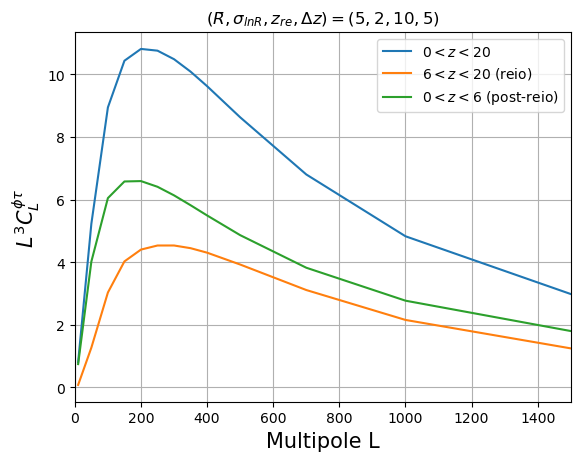

PyObject Text(0.5, 1.0, '$(R̄,σ_{lnR},z_{re},Δz)=(5,2,10,5)$')

In [30]:
# plot(collect(ℓrange),cℓτϕ)
plot(ℓs, 1e7 * ℓs.^3 .* cℓτϕ2, label=L"0<z<20")
plot(ℓs, 1e7 * ℓs.^3 .* cℓτϕ , label=L"$6<z<20$ (reio)")
plot(ℓs, 1e7 * ℓs.^3 .* cℓτϕ3, label=L"$0<z<6$ (post-reio)")
# plot(collect(ℓrange), collect(ℓrange).^3 .* cℓτϕ)
legend()
# ylim(1e-7,1e-4)
xlim(0,1500)
grid()
xlabel("Multipole L", size=15)
ylabel(L"L^3C_L^{ϕτ}", size=15)
title(L"(R̄,σ_{lnR},z_{re},Δz)=(5,2,10,5)")

In [40]:
ℓs, cℓτϕ  = GetCℓτϕ(R̄=1);
ℓs, cℓτϕ2 = GetCℓτϕ(R̄=5);
ℓs, cℓτϕ3 = GetCℓτϕ(Δz=5);

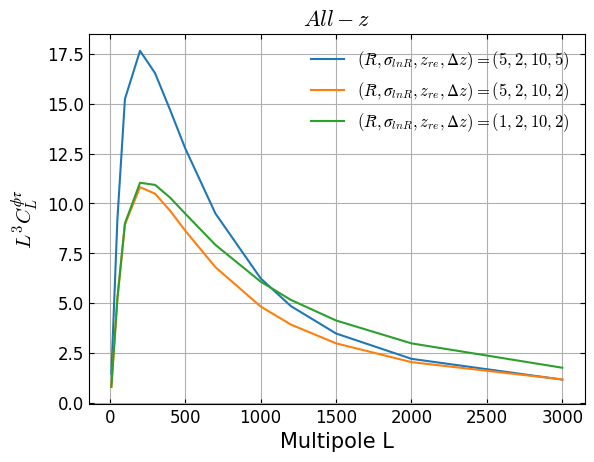

PyObject Text(0.5, 1.0, '$All-z$')

In [41]:
# plot(collect(ℓrange),cℓτϕ)
plot(ℓs, 1e7 * ℓs.^3 .* cℓτϕ3,  label=L"(R̄,σ_{lnR},z_{re},Δz)=(5,2,10,5)")
plot(ℓs, 1e7 * ℓs.^3 .* cℓτϕ2, label=L"(R̄,σ_{lnR},z_{re},Δz)=(5,2,10,2)")
plot(ℓs, 1e7 * ℓs.^3 .* cℓτϕ, label=L"(R̄,σ_{lnR},z_{re},Δz)=(1,2,10,2)")
# plot(collect(ℓrange), collect(ℓrange).^3 .* cℓτϕ)
legend()
# ylim(1e-7,1e-4)
# xlim(0,1500)
grid()
xlabel("Multipole L", size=15)
ylabel(L"L^3C_L^{ϕτ}", size=15)
title(L"All-z")

# Save to file

### "Optimistic" model 

In [31]:
ℓ, cℓτϕ = GetCℓτϕ(R̄=5, σlnR=log(2), zre=10, Δz=4)
Cℓτϕ = CMBLensing.extrapolate_Cℓs(2:8000, ℓ, cℓτϕ);
Cℓττ = CMBLensing.extrapolate_Cℓs(2:8000, 1:6000, GetCℓττ(R̄=5, σlnR=log(2), zre=10, Δz=4)(1:6000));
Cℓϕϕ = CMBLensing.extrapolate_Cℓs(2:8000, 1:1999, GetCℓκκ(Wκ)) / ℓ⁴ * 4;

In [34]:
@save "data/theory_spectra_optimistic.jld2" Cℓϕϕ Cℓτϕ Cℓττ

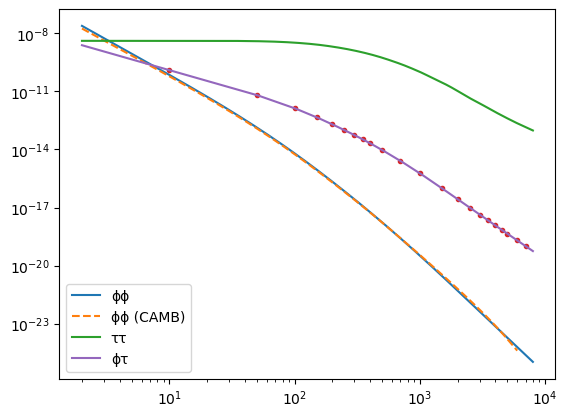

PyObject <matplotlib.legend.Legend object at 0x1554b6477520>

In [32]:
loglog(Cℓϕϕ, label="ϕϕ")
loglog(camb().total.ϕϕ, "--", label="ϕϕ (CAMB)")

loglog(Cℓττ, label="ττ")

loglog(ℓ, cℓτϕ, ".")
loglog(Cℓτϕ, label="ϕτ")

legend()

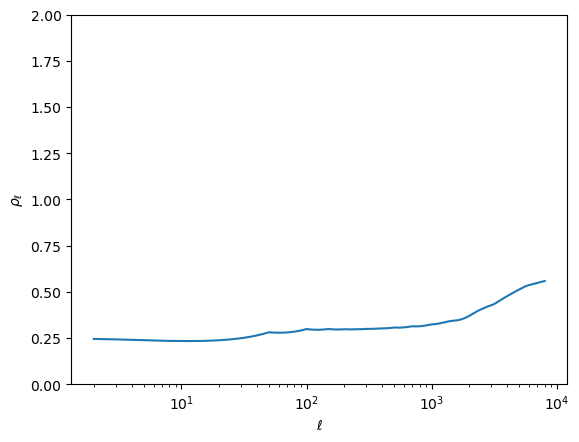

PyObject Text(25.000000000000007, 0.5, '$\\rho_\\ell$')

In [33]:
semilogx(Cℓτϕ/sqrt(Cℓϕϕ*Cℓττ))
ylim(0, 2)
xlabel(L"\ell")
ylabel(L"\rho_\ell")

### "Pessimistic" model 

In [36]:
R̄ = 1 
σlnR = 0.1
zre = 7
Δz = 1
ℓ, cℓτϕ = GetCℓτϕ(R̄=R̄, σlnR=σlnR, zre=zre, Δz=∆z)
Cℓτϕ = CMBLensing.extrapolate_Cℓs(2:8000, ℓ, cℓτϕ);
Cℓττ = CMBLensing.extrapolate_Cℓs(2:8000, 1:6000, GetCℓττ(R̄=R̄, σlnR=σlnR, zre=zre, Δz=Δz)(1:6000));
Cℓϕϕ = CMBLensing.extrapolate_Cℓs(2:8000, 1:1999, GetCℓκκ(Wκ)) / ℓ⁴ * 4;

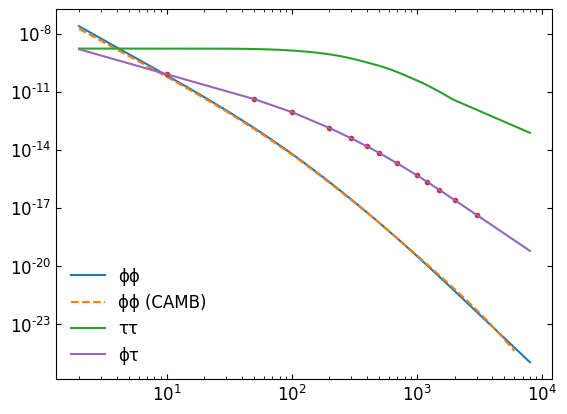

PyObject <matplotlib.legend.Legend object at 0x7f53b4d34ca0>

In [ ]:
loglog(Cℓϕϕ, label="ϕϕ")
loglog(camb().total.ϕϕ, "--", label="ϕϕ (CAMB)")

loglog(Cℓττ, label="ττ")

loglog(ℓ, cℓτϕ, ".")
loglog(Cℓτϕ, label="ϕτ")

legend()

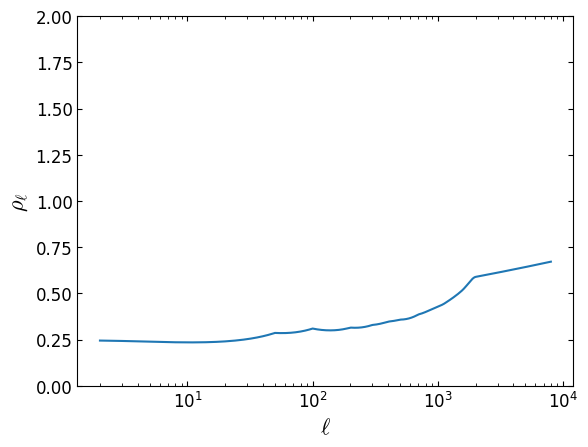

PyObject Text(30.0, 0.5, '$\\rho_\\ell$')

In [ ]:
semilogx(Cℓτϕ/sqrt(Cℓϕϕ*Cℓττ))
ylim(0, 2)
xlabel(L"\ell")
ylabel(L"\rho_\ell")

In [45]:
@save "data/theory_spectra_pessimistic.jld2" Cℓϕϕ Cℓτϕ Cℓττ

# Paper plot


In [37]:
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["font.size"] = 15
rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"
rcParams["axes.linewidth"]  = 1.2
rcParams["axes.labelsize"]  = 15
rcParams["axes.titlesize"]  = 18
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10
rcParams["xtick.major.size"] = 4
rcParams["ytick.major.size"] = 4
rcParams["xtick.minor.size"] = 3
rcParams["ytick.minor.size"] = 3
rcParams["legend.fontsize"]  = 14
rcParams["legend.frameon"]  = "False"
rcParams["xtick.major.width"] = 1
rcParams["ytick.major.width"] = 1
rcParams["xtick.minor.width"] = 1
rcParams["ytick.minor.width"] = 1

1

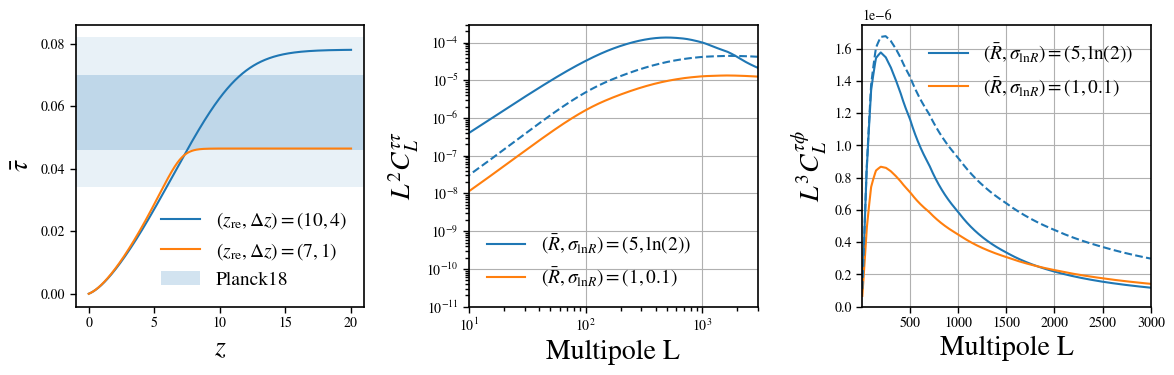

In [38]:
figure(figsize=(12,4))

subplot(131)
plot(0:0.01:20, τ̄.(0:0.01:20, zre=10, Δz=4), label=L"(z_{\rm re}, \Delta z)=(10,4)")
plot(0:0.01:20, τ̄.(0:0.01:20, zre=7, Δz=1), label=L"(z_{\rm re}, \Delta z)=(7,1)")
axhspan(0.058-0.012, 0.058+0.012, alpha=0.2, label="Planck18")
axhspan(0.058-2*0.012, 0.058+2*0.012, alpha=0.1)
xlabel(L"z", size=20)
ylabel(L"\bar{\tau}", size=20)
legend()

subplot(132)
loglog(CMBLensing.extrapolate_Cℓs(1:3000, 1:3000, collect(1:3000) .^2 .* GetCℓττ(R̄=5, σlnR=log(2), zre=10, Δz=4)(1:3000)),label=L"(\bar{R},\sigma_{\ln R})=(5,\ln(2))" )
loglog(CMBLensing.extrapolate_Cℓs(1:3000, 1:3000, collect(1:3000) .^2 .* GetCℓττ(R̄=1, σlnR=0.1, zre=7, Δz=1)(1:3000)),    label=L"(\bar{R},\sigma_{\ln R})=(1,0.1)" )
# loglog(CMBLensing.extrapolate_Cℓs(1:3000, 1:3000, collect(1:3000) .^2 .* GetCℓττ(R̄=1, σlnR=0.1, zre=10, Δz=4)(1:3000)), ls="--",  c="C0" )#label=L"(\bar{R},\sigma_{\ln R})=(1,0.1)" )
xlabel("Multipole L", size=20)
ylabel(L"L^2C_L^{ττ}", size=20)
xlim(10,3000)
ylim(1e-9,3e-4)
grid()
legend()

subplot(133)
plot(CMBLensing.extrapolate_Cℓs(2:3000, ℓ, ℓ.^3 .* GetCℓτϕ(R̄=5, σlnR=log(2), zre=10, Δz=4)[2]),label=L"(\bar{R},\sigma_{\ln R})=(5,\ln(2))" )
plot(CMBLensing.extrapolate_Cℓs(2:3000, ℓ, ℓ.^3 .* GetCℓτϕ(R̄=1, σlnR=0.1, zre=7, Δz=1)[2]),    label=L"(\bar{R},\sigma_{\ln R})=(1,0.1)" )
# plot(CMBLensing.extrapolate_Cℓs(2:3000, ℓ, ℓ.^3 .* GetCℓτϕ(R̄=1, σlnR=0.1, zre=10, Δz=4)[2]),  ls="--", c="C0")# label=L"(\bar{R},\sigma_{\ln R})=(1,0.1)" )
xlabel("Multipole L", size=20)
ylabel(L"L^3C_L^{τϕ}", size=20)
xlim(10,3000)
ylim(0,1.75e-6)
grid()
legend()

tight_layout()
savefig("theory_spectra_paper.pdf")
